# Sydney Golden

# Group 2

# Implement and train the assigned neural network architecture on CIFAR-10 data (read about pretrained modeling first). Submit the modeling work in a .ipynb file. It should include:


Our assigned neural network is ResNet.

# 1. Libraries, data import and necessary data preprocessing

Libraries:

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
from sklearn.linear_model import \
     (LinearRegression,
      LogisticRegression,
      Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import \
     (train_test_split,
      GridSearchCV)

Torch Inputs

In [ ]:
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset

Metrics

In [ ]:
from torchmetrics import (MeanAbsoluteError,
                          R2Score)
from torchinfo import summary

In [ ]:
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger

In [ ]:
from pytorch_lightning import seed_everything
seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

INFO:lightning_fabric.utilities.seed:Seed set to 0


In [ ]:
from torchvision.io import read_image
from torchvision.datasets import CIFAR10 #10 !!!!!
from torchvision.models import (resnet50,
                                ResNet50_Weights)
from torchvision.transforms import (Resize,
                                    Normalize,
                                    CenterCrop,
                                    ToTensor)

In [ ]:
from ISLP.torch import (SimpleDataModule,
                        SimpleModule,
                        ErrorTracker,
                        rec_num_workers)

In [ ]:
from glob import glob
import json


In [ ]:
from torch.utils.data import DataLoader
from torchvision.transforms import Compose, RandomHorizontalFlip
import torch.nn as nn

Data Preprocessing

[Hugging Face — ResNet-50 pretrained on CIFAR-10](https://huggingface.co/edadaltocg/resnet50_cifar10)


*    "A small resnet50 trained on cifar10"



Importing the pre-trained model

In [ ]:
import detectors
import timm

model = timm.create_model("resnet50_cifar10", pretrained=True)


Data Preprocessing: Resixing and normalizing

In [ ]:
# Load  pretrained model
model = timm.create_model("resnet50_cifar10", pretrained=True)

# Load CIFAR-10 dataset
dataset = CIFAR10(root="./data", train=False, download=True, transform=ToTensor())

resize    = Resize((224, 224), antialias=True)
normalize = Normalize([0.485, 0.456, 0.406],
                      [0.229, 0.224, 0.225])

# Index into dataset
imgs = torch.stack([resize(img) for img, label in
                    [dataset[i] for i in range(8)]])

imgs = normalize(imgs)
print(imgs.size())  # torch.Size([100, 3, 224, 224])

torch.Size([8, 3, 224, 224])


In [ ]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
summary(resnet_model,
        input_data=imgs,
        col_names=['input_size',
                   'output_size',
                   'num_params'])


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [8, 3, 224, 224]          [8, 1000]                 --
├─Conv2d: 1-1                            [8, 3, 224, 224]          [8, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [8, 64, 112, 112]         [8, 64, 112, 112]         128
├─ReLU: 1-3                              [8, 64, 112, 112]         [8, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [8, 64, 112, 112]         [8, 64, 56, 56]           --
├─Sequential: 1-5                        [8, 64, 56, 56]           [8, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [8, 64, 56, 56]           [8, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [8, 64, 56, 56]           [8, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [8, 64, 56, 56]           [8, 64, 56, 56]           128
│    │    └─ReLU: 3-3      

In [ ]:
resnet_model.eval() # Use eval() to predict on new data

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# 2. Implementation (think about how prediction performance can be improved)

Also note that the section on Pretrained CNN Models in Week5.ipynb does not contain training the model on new data, it is only doing inference on a few images)

In [ ]:
# Force full memory reset
import gc
import torch

# Clear all unused variables
gc.collect()
torch.cuda.empty_cache()

# Confirm how much memory is free
free, total = torch.cuda.mem_get_info()
print(f"Free: {free/1e9:.2f} GiB / Total: {total/1e9:.2f} GiB")

Free: 11.71 GiB / Total: 15.64 GiB


In [ ]:
# Training Setup - Create training set and resize
train_dataset = CIFAR10(root="./data", train=True, download=True, transform=Compose([
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
]))

# Updated dataset to include normalization, removed Resize
dataset = CIFAR10(root="./data", train=False, download=True, transform=Compose([
    ToTensor(),
    Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
]))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(dataset,       batch_size=64, shuffle=False, num_workers=2)

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Training & Validation Loops
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs     = model(imgs)
            total_loss += criterion(outputs, labels).item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

# Free memory from 224x224 imgs used in summary before training
del imgs
torch.cuda.empty_cache()

# Store metrics
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

# Run training
EPOCHS = 10
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = validate(model, val_loader, criterion)
    scheduler.step()
    torch.cuda.empty_cache()

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss:   {val_loss:.4f} Acc: {val_acc:.4f}")

# Save Model
torch.save(model.state_dict(), "resnet50_cifar10_finetuned.pth")
print("Model saved!")

Epoch 1/10 | Train Loss: 0.0829 Acc: 0.9720 | Val Loss:   0.2623 Acc: 0.9213
Epoch 2/10 | Train Loss: 0.0738 Acc: 0.9756 | Val Loss:   0.2736 Acc: 0.9222
Epoch 3/10 | Train Loss: 0.0545 Acc: 0.9814 | Val Loss:   0.2593 Acc: 0.9269
Epoch 4/10 | Train Loss: 0.0421 Acc: 0.9859 | Val Loss:   0.2380 Acc: 0.9324
Epoch 5/10 | Train Loss: 0.0276 Acc: 0.9912 | Val Loss:   0.2457 Acc: 0.9347
Epoch 6/10 | Train Loss: 0.0169 Acc: 0.9953 | Val Loss:   0.2647 Acc: 0.9290
Epoch 7/10 | Train Loss: 0.0114 Acc: 0.9969 | Val Loss:   0.2230 Acc: 0.9439
Epoch 8/10 | Train Loss: 0.0060 Acc: 0.9985 | Val Loss:   0.2216 Acc: 0.9450
Epoch 9/10 | Train Loss: 0.0030 Acc: 0.9993 | Val Loss:   0.2280 Acc: 0.9446
Epoch 10/10 | Train Loss: 0.0021 Acc: 0.9997 | Val Loss:   0.2208 Acc: 0.9466
Model saved!


In [ ]:
# Final Test Accuracy
test_loss, test_acc = validate(model, val_loader, criterion)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")
print(f"Final Test Loss:     {test_loss:.4f}")


Final Test Accuracy: 94.66%
Final Test Loss:     0.2208


The training accuracies were all greater than 97%, while the final test accuracy was slightly  lower at 94.66%.

# 3. Plot loss and accuracy on training vs test

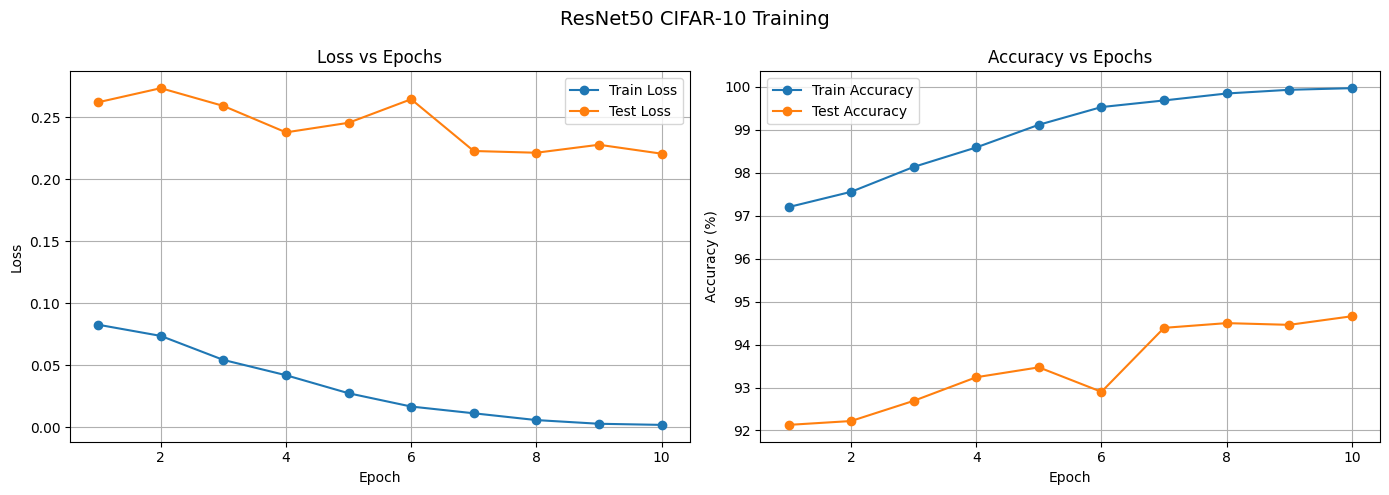

In [ ]:
epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, train_losses, label="Train Loss", marker="o")
ax1.plot(epochs, val_losses,   label="Test Loss",  marker="o")
ax1.set_title("Loss vs Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs, [a * 100 for a in train_accs], label="Train Accuracy", marker="o")
ax2.plot(epochs, [a * 100 for a in val_accs],   label="Test Accuracy",  marker="o")
ax2.set_title("Accuracy vs Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True)

plt.suptitle("ResNet50 CIFAR-10 Training", fontsize=14)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# 4. Written description on the following:
* Description on the pretrained model used
* Batch size, epoch, hyperparameter choice
* Analysis on the plot
* What you find interesting or different compared to CNN on CIFAR10 from last week





# Pretrained model description

The pre-trained model used was a resnet-50 model trained on the CIFAR-10 data by Hugging Face (See link in part 1). Provided is a list of training parameters that were utilized:

* config: scripts/train_configs/cifar10.json

* model: resnet50_cifar10

* dataset: cifar10

* batch_size: 128

* epochs: 300

* validation_frequency: 5

* seed: 1

* criterion: CrossEntropyLoss

* criterion_kwargs: {}

* optimizer: SGD

* lr: 0.1

* optimizer_kwargs: {'momentum': 0.9, 'weight_decay': 0.0005, 'nesterov': 'True'}

* scheduler: ReduceLROnPlateau

* scheduler_kwargs: {'factor': 0.1, 'patience': 3, 'threshold': 0.001, 'mode': 'max'}

* debug: False


# Hyperparameters

I used a batch size of 64 and 10 epochs to train the model. In terms of other hyperparameters, the model has a learning rate of 1e-4 and is small to prevent pretrained weights being overwritten. The weight_decay was small at 1e-4, and it reduces overfitting by penalizing large weights in the model during training.

# Plot

Increasing the amount of epochs used had a more consistent impact on descreasing the training loss as opposed to the testing loss. The second plot shows that the more epochs in this model, the greater the training and testing accuracy. Test accuracy increases except for at 6 epochs, where there is a slight divet.

#Comparison

In comparison to the CNN used on Cifar-10 last week, the resnet model applies slightly different methods to the code. There are no classes as building blocks in the resnet module when it was necessary to build the model in CNN. Both required defining functions to process the data, but only the resnet model required a for loop when training.